# Atmospheric Transmission at the FURST Launch Sites

The Full-sun Ultraviolet Rocket Spectrometer (FURST) measures the solar spectrum
in the far ultraviolet (FUV, 120 to 180 nm), a spectral range which is strongly
absorbed by molecular oxygen in the Earth's atmosphere.
Since the residual atmosphere above a sounding rocket still absorbs some FUV
light, this report estimates the transmission of the atmosphere along the line
of sight from the payload to the Sun as a function of observing height
(150 to 300 km), launch date, and launch site, for two candidate launch sites:

- Poker Flat Research Range, Alaska
- White Sands Missile Range, New Mexico

The calculation proceeds in three steps:

1. Compute the altitude of the Sun at local noon for every day of the year
   at each launch site using `astropy.coordinates`.
2. Compute the column density of molecular oxygen along the slant path from the
   payload to the Sun (spherical Earth geometry) using number densities from
   the U.S. Standard Atmosphere 1976 (NASA-TM-X-74335), evaluated with the
   [`ussa1976`](https://pypi.org/project/ussa1976/) package.
3. Compute the transmission using Beer's law and photoabsorption cross
   sections of molecular oxygen compiled from the literature.

## Assumptions and caveats

- Molecular oxygen is the only absorber considered.
  This is a good approximation in the FURST bandpass:
  molecular nitrogen only absorbs appreciably below about 100 nm,
  and the photoionization threshold of atomic oxygen is 91.1 nm.
- Resonant scattering by atomic oxygen at the O I 130.4 nm triplet
  (and by atomic hydrogen at Lyman alpha) is not modeled,
  so the transmission computed here is an overestimate at exactly those
  wavelengths.
- The U.S. Standard Atmosphere 1976 is a static mean atmosphere,
  so the date dependence computed here enters only through the solar zenith
  angle.
  The real thermospheric density varies significantly with season and solar
  activity, and a climatological model such as NRLMSIS could be substituted
  for a more detailed study.
- The oxygen cross sections used here are coarse band averages in the
  structured spectral regions (120 to 131 nm and above 175 nm).
- Atmospheric refraction is neglected, which is a good approximation at these
  heights.


In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants
import astropy.time
import astropy.coordinates
import astropy.visualization
import named_arrays as na
import ussa1976

In [3]:
astropy.visualization.quantity_support();

## Launch sites and dates

Define the coordinates of the two candidate launch sites,
the year to consider,
and the names of the logical axes used throughout this report.
The proposed launch date, March 8, is highlighted throughout this report.

In [4]:
year = 2027
date_launch = f"{year}-03-08"

axis_site = "site"
axis_time = "time"
axis_height = "height"
axis_distance = "distance"
axis_wavelength = "wavelength"

sites = {
    "Poker Flat Research Range": astropy.coordinates.EarthLocation(
        lat=65.1192 * u.deg,
        lon=-147.4322 * u.deg,
        height=213 * u.m,
    ),
    "White Sands Missile Range": astropy.coordinates.EarthLocation(
        lat=32.4177 * u.deg,
        lon=-106.3717 * u.deg,
        height=1225 * u.m,
    ),
}

## Altitude of the Sun

Solar sounding rocket flights are usually launched close to local noon,
when the Sun is highest in the sky and the slant path through the atmosphere
is shortest.
For each day of the year, sample the altitude of the Sun every 10 minutes and
take the daily maximum, which is the altitude of the Sun at local (apparent)
noon.

Since these dates are in the future, `astropy` warns that its Earth orientation
tables must be extrapolated.
The resulting pointing error is tiny compared to the accuracy needed here,
so the warnings are suppressed.

In [5]:
t0 = astropy.time.Time(f"{year}-01-01", scale="utc")
num_days = 365
day = np.arange(num_days)
hour = np.arange(0, 24, 1 / 6)

times = t0 + day[:, np.newaxis] * u.day + hour[np.newaxis, :] * u.hr

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sun = astropy.coordinates.get_sun(times)
    alt_noon = []
    for site in sites:
        frame = astropy.coordinates.AltAz(obstime=times, location=sites[site])
        alt = sun.transform_to(frame).alt.deg
        alt_noon.append(alt.max(axis=1))

alt_noon = na.ScalarArray(np.stack(alt_noon) << u.deg, axes=(axis_site, axis_time))
date = na.ScalarArray((t0 + day * u.day).datetime64, axes=(axis_time,))

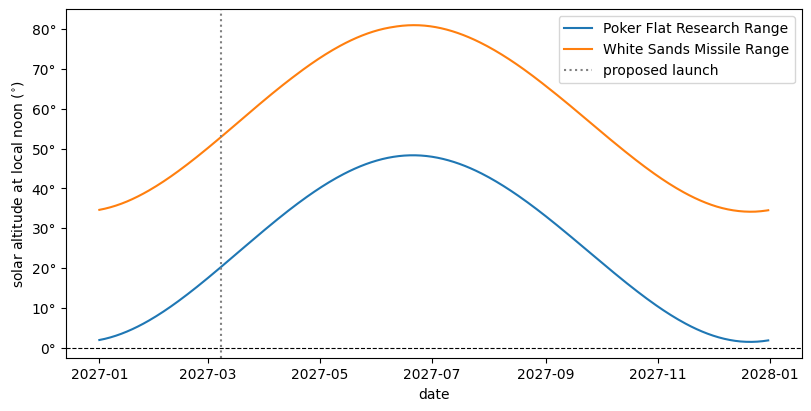

In [6]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for i, site in enumerate(sites):
    na.plt.plot(date, alt_noon[{axis_site: i}], ax=ax, axis=axis_time, label=site)
ax.axvline(np.datetime64(date_launch), color="gray", linestyle=":", label="proposed launch")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("date")
ax.set_ylabel(f"solar altitude at local noon ({u.deg:latex_inline})")
ax.legend();

## The U.S. Standard Atmosphere 1976

The U.S. Standard Atmosphere 1976 tabulates the number density of the major
atmospheric species from sea level up to 1000 km.
Evaluate the model on a fine height grid and plot the number densities of the
three most abundant thermospheric species.

In [7]:
z_model = np.linspace(0, 1000, num=2001) * u.km

atmosphere = ussa1976.compute(z=z_model.to_value(u.m), variables=["n"])

n_o2_model = atmosphere["n"].sel(s="O2").values << u.m**-3

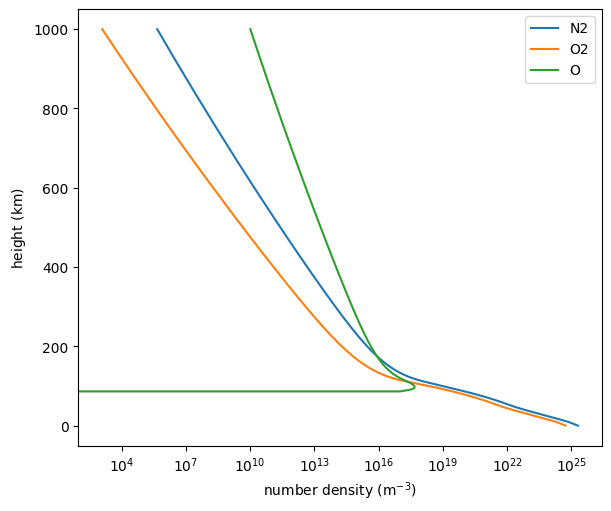

In [8]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
for species in ("N2", "O2", "O"):
    ax.plot(
        atmosphere["n"].sel(s=species).values,
        z_model.to_value(u.km),
        label=species,
    )
ax.set_xscale("log")
ax.set_xlabel(f"number density ({u.m**-3:latex_inline})")
ax.set_ylabel(f"height ({u.km:latex_inline})")
ax.legend();

In [9]:
def number_density_o2(h: na.AbstractScalar) -> na.ScalarArray:
    """
    The number density of molecular oxygen at a height `h` above sea level,
    interpolated log-linearly from the model grid.
    Heights outside the grid are clamped to the nearest endpoint.
    """
    h = h.explicit
    result = np.interp(
        x=h.ndarray.to_value(u.km),
        xp=z_model.to_value(u.km),
        fp=np.log(n_o2_model.to_value(u.m**-3)),
    )
    return na.ScalarArray(np.exp(result) << u.m**-3, axes=h.axes)

## Slant column density

The line of sight from the payload at height $h$ to the Sun makes an angle $z$
(the solar zenith angle) with the local vertical.
Parameterizing the line of sight by the distance $s$ from the payload,
the height above sea level of a point on the path is

$$ h(s) = \sqrt{(R_\oplus + h)^2 + s^2 + 2 (R_\oplus + h) s \cos z} - R_\oplus, $$

where $R_\oplus$ is the radius of the Earth.
The slant column density of molecular oxygen is then

$$ N_{\mathrm{O}_2} = \int_0^\infty n_{\mathrm{O}_2}(h(s)) \, ds, $$

evaluated here with a midpoint rule on a uniform grid.

The spherical geometry is important:
at Poker Flat in winter the Sun is only a degree or two above the horizon at
noon, where a plane-parallel approximation would fail badly.
If the line of sight intersects the ground, the interpolation clamps to the
sea-level density and the resulting optical depth is enormous,
so occultation by the Earth is handled naturally.

In [10]:
height = na.linspace(150, 300, axis=axis_height, num=16) * u.km

zenith = 90 * u.deg - alt_noon

distance_max = 3000 * u.km
num_distance = 600
distance = na.linspace(0, 1, axis=axis_distance, num=num_distance, centers=True) * distance_max
d_distance = distance_max / num_distance

r0 = astropy.constants.R_earth + height
r = np.sqrt(np.square(r0) + np.square(distance) + 2 * r0 * distance * np.cos(zenith))
h_path = r - astropy.constants.R_earth

column_o2 = (number_density_o2(h_path) * d_distance).sum(axis_distance)
column_o2 = column_o2.to(u.cm**-2)

## Photoabsorption cross section of molecular oxygen

Approximate photoabsorption cross sections of molecular oxygen over the FURST
bandpass, compiled from Watanabe (1958) and Hudson (1971).
The 131 to 175 nm range is dominated by the smooth Schumann-Runge continuum,
which peaks near 142.5 nm.
Below about 131 nm and above about 175 nm the spectrum is banded,
and the values used here are coarse band averages.
The value at H I Lyman alpha (121.6 nm) is the well-known deep window in the
molecular oxygen spectrum which makes Lyman alpha observations possible from
relatively low altitudes.

In [11]:
wavelength = na.ScalarArray(
    ndarray=[120.0, 121.6, 125.0, 130.0, 135.0, 140.0, 142.5, 145.0,
             150.0, 155.0, 160.0, 165.0, 170.0, 175.0, 180.0] * u.nm,
    axes=(axis_wavelength,),
)
cross_section_o2 = na.ScalarArray(
    ndarray=[4.0e-19, 1.0e-20, 7.0e-19, 8.0e-19, 4.0e-18, 1.2e-17, 1.5e-17, 1.4e-17,
             1.2e-17, 8.0e-18, 4.5e-18, 2.0e-18, 6.0e-19, 1.5e-19, 1.5e-20] * u.cm**2,
    axes=(axis_wavelength,),
)

lines_furst = {
    "H I": 121.6 * u.nm,
    "O I": 130.4 * u.nm,
    "C II": 133.5 * u.nm,
    "Si IV": 139.4 * u.nm,
    "C IV": 154.9 * u.nm,
    "C I": 165.7 * u.nm,
}

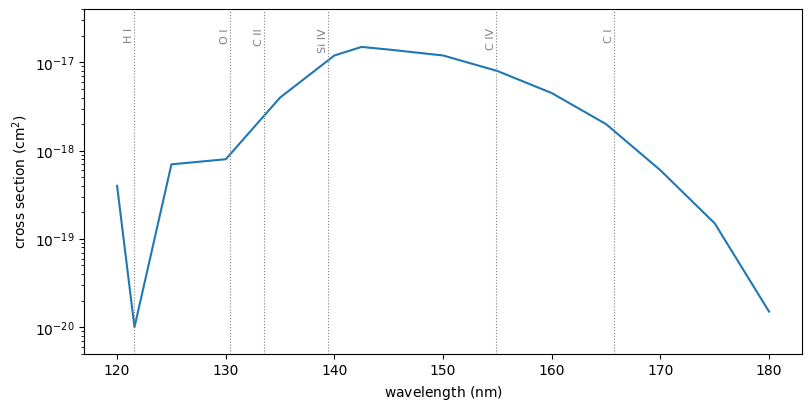

In [12]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
na.plt.plot(wavelength, cross_section_o2, ax=ax, axis=axis_wavelength)
for line in lines_furst:
    ax.axvline(lines_furst[line], color="gray", linestyle=":", linewidth=0.8)
    ax.text(
        x=lines_furst[line].to_value(u.nm),
        y=2.5e-17,
        s=line,
        rotation=90,
        ha="right",
        va="top",
        fontsize=8,
        color="gray",
    )
ax.set_yscale("log")
ax.set_ylim(5e-21, 4e-17)
ax.set_xlabel(f"wavelength ({u.nm:latex_inline})")
ax.set_ylabel(f"cross section ({u.cm**2:latex_inline})");

## Transmission

Applying Beer's law,

$$ T(\lambda, h, t) = e^{-\sigma_{\mathrm{O}_2}(\lambda) N_{\mathrm{O}_2}(h, t)}, $$

gives the transmission as a function of wavelength, observing height,
launch site, and date.
The plots below use the peak of the Schumann-Runge continuum as the worst-case
wavelength.

In [13]:
optical_depth = cross_section_o2 * column_o2
transmission = np.exp(-optical_depth)

index_worst = np.argmax(cross_section_o2, axis=axis_wavelength)
wavelength_worst = wavelength[index_worst]
transmission_worst = transmission[index_worst]

dates_season = {
    "proposed launch (Mar 8)": date_launch,
    "spring equinox": f"{year}-03-20",
    "summer solstice": f"{year}-06-21",
    "fall equinox": f"{year}-09-22",
    "winter solstice": f"{year}-12-21",
}


def index_date(d: str) -> int:
    return int(round((astropy.time.Time(d) - t0).jd))

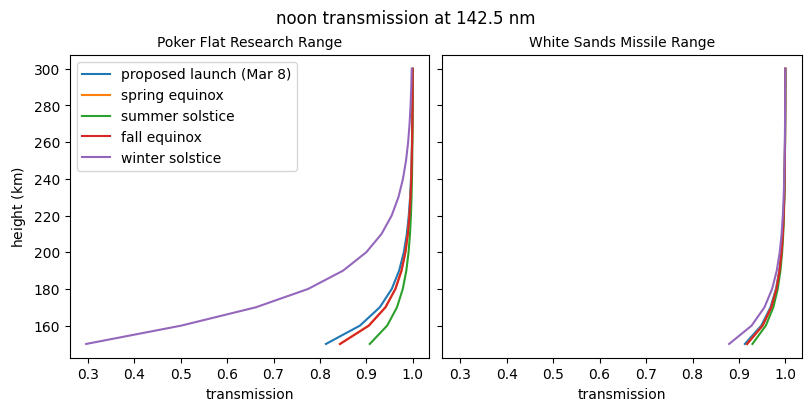

In [14]:
fig, axs = plt.subplots(
    ncols=len(sites),
    sharex=True,
    sharey=True,
    figsize=(8, 4),
    constrained_layout=True,
)
for i, site in enumerate(sites):
    ax = axs[i]
    for season in dates_season:
        na.plt.plot(
            transmission_worst[{axis_site: i, axis_time: index_date(dates_season[season])}],
            height,
            ax=ax,
            axis=axis_height,
            label=season,
        )
    ax.set_title(site, fontsize=10)
    ax.set_xlabel("transmission")
axs[0].set_ylabel(f"height ({u.km:latex_inline})")
axs[0].legend()
fig.suptitle(f"noon transmission at {wavelength_worst.ndarray:.1f}");

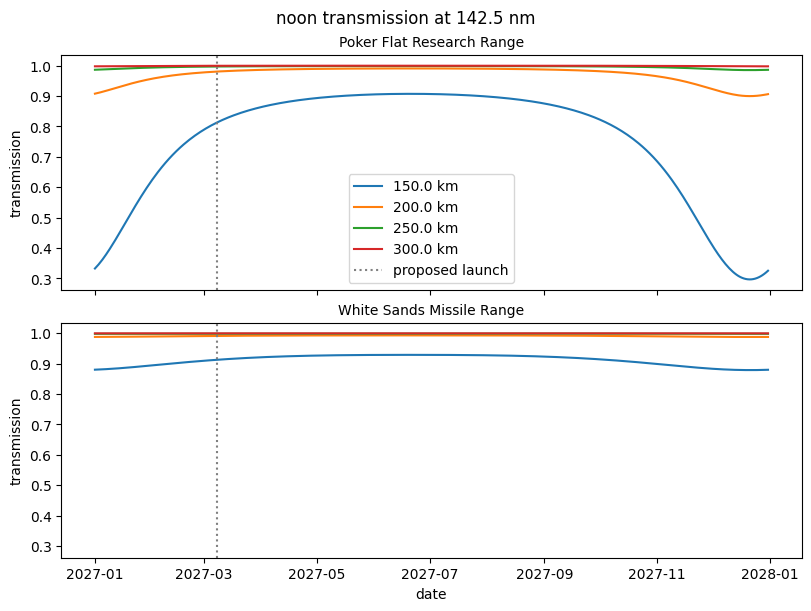

In [15]:
heights_plot = [150, 200, 250, 300] * u.km

fig, axs = plt.subplots(
    nrows=len(sites),
    sharex=True,
    sharey=True,
    figsize=(8, 6),
    constrained_layout=True,
)
for i, site in enumerate(sites):
    ax = axs[i]
    for h in heights_plot:
        index_h = np.argmin(np.abs(height - h), axis=axis_height)
        na.plt.plot(
            date,
            transmission_worst[index_h][{axis_site: i}],
            ax=ax,
            axis=axis_time,
            label=f"{h}",
        )
    ax.axvline(np.datetime64(date_launch), color="gray", linestyle=":", label="proposed launch")
    ax.set_title(site, fontsize=10)
    ax.set_ylabel("transmission")
axs[~0].set_xlabel("date")
axs[0].legend()
fig.suptitle(f"noon transmission at {wavelength_worst.ndarray:.1f}");

The spectral dependence of the transmission at a representative observing
height of 200 km:

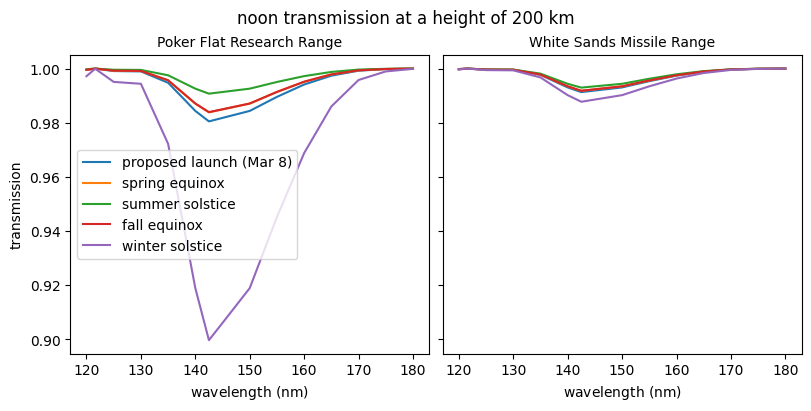

In [16]:
index_200 = np.argmin(np.abs(height - 200 * u.km), axis=axis_height)

fig, axs = plt.subplots(
    ncols=len(sites),
    sharex=True,
    sharey=True,
    figsize=(8, 4),
    constrained_layout=True,
)
for i, site in enumerate(sites):
    ax = axs[i]
    for season in dates_season:
        na.plt.plot(
            wavelength,
            transmission[index_200][{axis_site: i, axis_time: index_date(dates_season[season])}],
            ax=ax,
            axis=axis_wavelength,
            label=season,
        )
    ax.set_title(site, fontsize=10)
    ax.set_xlabel(f"wavelength ({u.nm:latex_inline})")
axs[0].set_ylabel("transmission")
axs[0].legend()
fig.suptitle("noon transmission at a height of 200 km");

In [17]:
index_lya = {axis_wavelength: 1}
index_250 = np.argmin(np.abs(height - 250 * u.km), axis=axis_height)

for i, site in enumerate(sites):
    print(site)
    for season in ("proposed launch (Mar 8)", "summer solstice", "winter solstice"):
        index = {axis_site: i, axis_time: index_date(dates_season[season])} | index_250
        t_lya = transmission[index_lya][index]
        t_worst = transmission_worst[index]
        print(
            f"  {season}:"
            f" T(Lyman alpha, 250 km) = {t_lya.ndarray:.3f},"
            f" T({wavelength_worst.ndarray:.1f}, 250 km) = {t_worst.ndarray:.3f}"
        )

Poker Flat Research Range
  proposed launch (Mar 8): T(Lyman alpha, 250 km) = 1.000, T(142.5 nm, 250 km) = 0.997
  summer solstice: T(Lyman alpha, 250 km) = 1.000, T(142.5 nm, 250 km) = 0.999
  winter solstice: T(Lyman alpha, 250 km) = 1.000, T(142.5 nm, 250 km) = 0.985
White Sands Missile Range
  proposed launch (Mar 8): T(Lyman alpha, 250 km) = 1.000, T(142.5 nm, 250 km) = 0.999
  summer solstice: T(Lyman alpha, 250 km) = 1.000, T(142.5 nm, 250 km) = 0.999
  winter solstice: T(Lyman alpha, 250 km) = 1.000, T(142.5 nm, 250 km) = 0.998


## Conclusions

- On the proposed launch date of March 8, the Sun reaches a noon altitude of
  20.2 degrees at Poker Flat and 52.8 degrees at White Sands.
- On that date, at the worst-case wavelength (the 142.5 nm peak of the
  Schumann-Runge continuum), the noon transmission at Poker Flat is
  0.81 at 150 km, 0.98 at 200 km, and better than 0.99 above 250 km.
  The corresponding values at White Sands are 0.91, 0.99, and better
  than 0.99.
  A launch from either site on March 8 is therefore comfortable at these
  observing heights, with only a modest advantage for White Sands.
- Over the full year, the noon transmission at White Sands is at least 0.88
  at 150 km and at least 0.99 at 200 km.
  Poker Flat is comparable in summer, but near the winter solstice
  (noon solar altitude of 1.4 degrees) the long slant path through the
  thermosphere reduces the worst-case transmission to about 0.30 at 150 km and
  0.90 at 200 km, recovering to nearly unity at 300 km.
- H I Lyman alpha is essentially unattenuated above 150 km at both sites on
  every day of the year, thanks to the deep window in the molecular oxygen
  cross section at 121.6 nm.
- The absorption in the Schumann-Runge continuum below about 200 km is
  measurable on any date and would need to be corrected during data reduction.
  That correction is least certain at the O I 130.4 nm resonance line,
  where scattering by atomic oxygen is not modeled here.